In [1]:
%load_ext autoreload
%autoreload 2

import os
import random
import numpy as np
import pandas as pd
import sys
import torch
from pathlib import Path
import matplotlib.pyplot as plt

SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_default_dtype(torch.float64)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
if torch.backends.cudnn.is_available():
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

def find_root(current_path, marker="setup.py"):
    current_path = Path(current_path).resolve()
    for parent in [current_path] + list(current_path.parents):
        if (parent / marker).exists():
            return parent
    return current_path

PROJECT_ROOT = find_root(Path.cwd())
DATASETS_DIR = PROJECT_ROOT / "data" / "datasets"
RESULTS_DIR = PROJECT_ROOT / "data" / "results"
ASSETS_DIR = PROJECT_ROOT / "experiments" / "shared" / "assets"

if str(PROJECT_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT / "src"))

from rl_methods.sbeed import (
    SBEEDSolverSGDRho,
    DiscreteMDPSpec,
    TabularStateFeatures,
    TabularStateActionFeatures,
    SBEEDEvaluator,
)


/home/mauro/anaconda3/envs/fogas/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## MDP

In [2]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0
goal_grid = 8

In [3]:
def to_rc(s):
    return divmod(int(s), 3)

def to_s(r, c):
    return r * 3 + c

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s == goal_grid:
        return goal_grid

    r, c = to_rc(s)

    if a == 0:      # Up
        r = max(0, r - 1)
    elif a == 1:    # Down
        r = min(2, r + 1)
    elif a == 2:    # Left
        c = max(0, c - 1)
    elif a == 3:    # Right
        c = min(2, c + 1)

    return to_s(r, c)


### Features

In [4]:
value_features = TabularStateFeatures(n_states=N)
rho_features = TabularStateActionFeatures(n_states=N, n_actions=A)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    x0=x_0,
)

def reward_fn(s, a, sp):
    # Same idea as your old omega: reward 1 at the goal.
    return 1.0 if int(sp) == goal_grid else -0.1

## Solving it

In [5]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    ridge=1e-6,
    lr_value=1e-2,
    lr_rho=1e-2,
    lr_policy=1e-2,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=3000,
    batch_size=64,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=3000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    behavior="policy",
    epsilon=0.1,
    terminal_states={goal_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)


episode=50/3000 buffer=1050 objective=0.032827 primal_mse=0.033160 dual_mse=0.033318 theta_grad=7.847e-02 policy_grad=8.120e-02
episode=100/3000 buffer=2050 objective=0.030200 primal_mse=0.030473 dual_mse=0.027369 theta_grad=4.377e-02 policy_grad=3.359e-02
episode=150/3000 buffer=3000 objective=0.029656 primal_mse=0.029891 dual_mse=0.023545 theta_grad=5.624e-02 policy_grad=6.791e-02
episode=200/3000 buffer=3000 objective=0.029896 primal_mse=0.030112 dual_mse=0.021617 theta_grad=5.173e-02 policy_grad=5.548e-02
episode=250/3000 buffer=3000 objective=0.030827 primal_mse=0.031042 dual_mse=0.021443 theta_grad=3.394e-02 policy_grad=3.381e-02
episode=300/3000 buffer=3000 objective=0.031712 primal_mse=0.031930 dual_mse=0.021854 theta_grad=3.208e-02 policy_grad=3.902e-02
episode=350/3000 buffer=3000 objective=0.031697 primal_mse=0.031904 dual_mse=0.020750 theta_grad=7.045e-02 policy_grad=6.459e-02
episode=400/3000 buffer=3000 objective=0.031280 primal_mse=0.031477 dual_mse=0.019672 theta_grad=3

In [6]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
    terminal_states={goal_grid}, 
)

evaluator.print_policy()

stats = evaluator.reward_comparison(
    n_trajectories=10,
    max_steps=100,
    seed=42,
)

print(f"SBEED avg reward:    {stats['learned']['avg_reward']:.4f}")
print(f"SBEED reward std:    {stats['learned']['std_reward']:.4f}")
print(f"Uniform avg reward:  {stats['uniform']['avg_reward']:.4f}")
print(f"Uniform reward std:  {stats['uniform']['std_reward']:.4f}")
print(f"Optimal avg reward:  {stats['optimal']['avg_reward']:.4f}")
print(f"Optimal reward std:  {stats['optimal']['std_reward']:.4f}")


========== SBEED POLICY ==========

State 0: pi(0|0)=0.041  pi(1|0)=0.445  pi(2|0)=0.040  pi(3|0)=0.474  --> best action: 3
State 1: pi(0|1)=0.072  pi(1|1)=0.518  pi(2|1)=0.035  pi(3|1)=0.375  --> best action: 1
State 2: pi(0|2)=0.072  pi(1|2)=0.810  pi(2|2)=0.046  pi(3|2)=0.072  --> best action: 1
State 3: pi(0|3)=0.039  pi(1|3)=0.326  pi(2|3)=0.068  pi(3|3)=0.567  --> best action: 3
State 4: pi(0|4)=0.026  pi(1|4)=0.409  pi(2|4)=0.025  pi(3|4)=0.540  --> best action: 3
State 5: pi(0|5)=0.009  pi(1|5)=0.967  pi(2|5)=0.009  pi(3|5)=0.015  --> best action: 1
State 6: pi(0|6)=0.051  pi(1|6)=0.081  pi(2|6)=0.078  pi(3|6)=0.790  --> best action: 3
State 7: pi(0|7)=0.010  pi(1|7)=0.017  pi(2|7)=0.010  pi(3|7)=0.963  --> best action: 3
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0


SBEED avg reward:    0.6800
SBEED reward std:    0.0400
Uniform avg reward:  -1.6600
Uniform reward std:  2.0071
Optimal avg reward:  0.7000
Optimal reward std:  0.0000


# Wall and pit

In [7]:
states = torch.arange(9, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

x_0 = 0

goal_grid = 8
pit_grid = 5
wall_states = {4}
terminal_states = {goal_grid, pit_grid}

def next_state(s, a):
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = divmod(s, 3)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < 3 and 0 <= new_col < 3):
        return s

    sp = new_row * 3 + new_col

    if sp in wall_states:
        return s

    return sp

value_features = TabularStateFeatures(n_states=N)
rho_features = TabularStateActionFeatures(n_states=N, n_actions=A)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    x0=x_0,
)

def reward_fn(s, a, sp):
    if int(sp) == goal_grid:
        return 1.0
    if int(sp) == pit_grid:
        return -1.0
    return -0.1

In [8]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.01,
    eta=0.01,
    ridge=1e-6,
    lr_value=1e-2,
    lr_policy=1e-2,
    lr_rho=1e-2,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=6000,
    batch_size=128,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=2000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=50,
    start_state=x_0,
    behavior="policy",
    epsilon=0.2,
    terminal_states={goal_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/2000 buffer=1050 objective=0.168108 primal_mse=0.169431 dual_mse=0.132283 theta_grad=2.288e-02 policy_grad=5.081e-02
episode=100/2000 buffer=2050 objective=0.146190 primal_mse=0.147161 dual_mse=0.097158 theta_grad=5.294e-02 policy_grad=9.020e-02
episode=150/2000 buffer=3050 objective=0.140506 primal_mse=0.141310 dual_mse=0.080345 theta_grad=2.717e-02 policy_grad=7.274e-02
episode=200/2000 buffer=4050 objective=0.136887 primal_mse=0.137568 dual_mse=0.068047 theta_grad=2.824e-02 policy_grad=6.954e-02
episode=250/2000 buffer=5050 objective=0.130307 primal_mse=0.130879 dual_mse=0.057220 theta_grad=2.377e-02 policy_grad=6.391e-02
episode=300/2000 buffer=6000 objective=0.133808 primal_mse=0.134318 dual_mse=0.051005 theta_grad=3.900e-02 policy_grad=4.969e-02
episode=350/2000 buffer=6000 objective=0.131945 primal_mse=0.132377 dual_mse=0.043163 theta_grad=3.223e-02 policy_grad=8.155e-02
episode=400/2000 buffer=6000 objective=0.130012 primal_mse=0.130395 dual_mse=0.038336 theta_grad=4

In [9]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
    terminal_states={goal_grid}, 
)

evaluator.print_policy()

stats = evaluator.reward_comparison(
    n_trajectories=10,
    max_steps=100,
    seed=42,
)

print(f"SBEED avg reward:    {stats['learned']['avg_reward']:.4f}")
print(f"SBEED reward std:    {stats['learned']['std_reward']:.4f}")
print(f"Uniform avg reward:  {stats['uniform']['avg_reward']:.4f}")
print(f"Uniform reward std:  {stats['uniform']['std_reward']:.4f}")
print(f"Optimal avg reward:  {stats['optimal']['avg_reward']:.4f}")
print(f"Optimal reward std:  {stats['optimal']['std_reward']:.4f}")


========== SBEED POLICY ==========

State 0: pi(0|0)=0.020  pi(1|0)=0.953  pi(2|0)=0.020  pi(3|0)=0.007  --> best action: 1
State 1: pi(0|1)=0.210  pi(1|1)=0.208  pi(2|1)=0.504  pi(3|1)=0.078  --> best action: 2
State 2: pi(0|2)=0.247  pi(1|2)=0.045  pi(2|2)=0.461  pi(3|2)=0.247  --> best action: 2
State 3: pi(0|3)=0.006  pi(1|3)=0.965  pi(2|3)=0.015  pi(3|3)=0.015  --> best action: 1
State 4: pi(0|4)=0.250  pi(1|4)=0.250  pi(2|4)=0.250  pi(3|4)=0.250  --> best action: 0
State 5: pi(0|5)=0.085  pi(1|5)=0.413  pi(2|5)=0.130  pi(3|5)=0.372  --> best action: 1
State 6: pi(0|6)=0.005  pi(1|6)=0.012  pi(2|6)=0.012  pi(3|6)=0.971  --> best action: 3
State 7: pi(0|7)=0.009  pi(1|7)=0.009  pi(2|7)=0.003  pi(3|7)=0.980  --> best action: 3
State 8: pi(0|8)=0.250  pi(1|8)=0.250  pi(2|8)=0.250  pi(3|8)=0.250  --> best action: 0


SBEED avg reward:    0.7000
SBEED reward std:    0.0000
Uniform avg reward:  -50.2100
Uniform reward std:  40.0439
Optimal avg reward:  0.7000
Optimal reward std:  0.000

# 5 grid

## Deterministic

In [10]:
states = torch.arange(25, dtype=torch.long)
actions = torch.arange(4, dtype=torch.long)

N = len(states)
A = len(actions)
gamma = 0.9

grid_size = 5

x_0 = 0

goal_grid = 24
pit_grid = 18

wall_states = {6, 7, 12}
terminal_states = {goal_grid, pit_grid}

def state_to_pos(s):
    s = int(s)
    return divmod(s, grid_size)


def pos_to_state(row, col):
    return row * grid_size + col


def move_deterministic(s, a):
    """
    Deterministic transition used internally.

    This function returns the next state after applying action a.
    It does not return probabilities.
    """
    s = int(s)
    a = int(a)

    if s in terminal_states:
        return s

    row, col = state_to_pos(s)

    if a == 0:      # up
        new_row, new_col = row - 1, col
    elif a == 1:    # down
        new_row, new_col = row + 1, col
    elif a == 2:    # left
        new_row, new_col = row, col - 1
    elif a == 3:    # right
        new_row, new_col = row, col + 1
    else:
        raise ValueError("action must be in {0,1,2,3}")

    if not (0 <= new_row < grid_size and 0 <= new_col < grid_size):
        return s

    sp = pos_to_state(new_row, new_col)

    if sp in wall_states:
        return s

    return sp


def transition_probs(s, a):
    """
    Return transition distribution for state-action pair.

    Returns:
        List of (next_state, probability)
    """
    sp = move_deterministic(s, a)
    return [(sp, 1.0)]


def next_state(s, a):
    """
    Sample or select next state.

    For deterministic transitions this just returns the only possible next state.
    This keeps compatibility with your previous code.
    """
    probs = transition_probs(s, a)
    return probs[0][0]


def reward_fn(s, a, sp):
    sp = int(sp)

    if sp == goal_grid:
        return 1.0

    if sp == pit_grid:
        return -1.0

    return -0.1


value_features = TabularStateFeatures(n_states=N)
rho_features = TabularStateActionFeatures(n_states=N, n_actions=A)

mdp_spec = DiscreteMDPSpec(
    n_states=N,
    n_actions=A,
    gamma=gamma,
    value_features=value_features,
    rho_features=rho_features,
    x0=x_0,
)

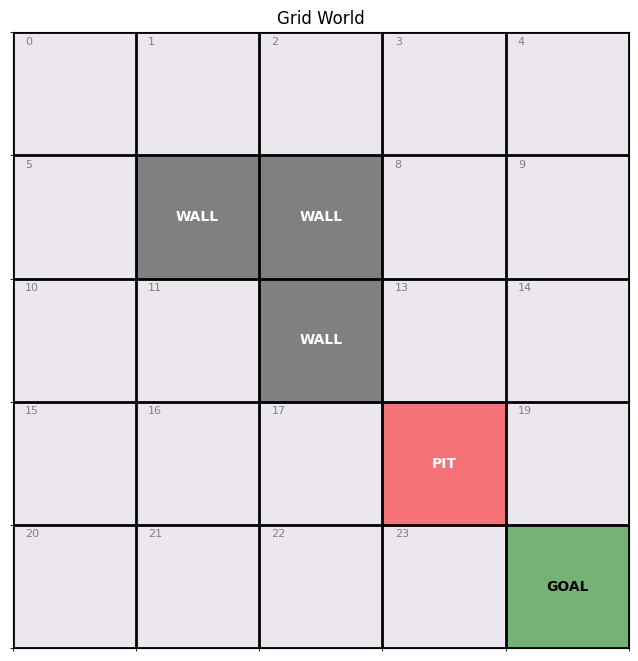

In [11]:
def plot_grid(values=None, policy=None, title="Grid World"):
    """
    Plots the 5x5 grid with environment features.
    
    Args:
        values (torch.Tensor or np.ndarray): Optional 1D array of state values to visualize as colors.
        policy (torch.Tensor or np.ndarray): Optional 2D array [N, A] or 1D array of best actions to show as arrows.
        title (str): Plot title.
    """
    fig, ax = plt.subplots(figsize=(8, 8))
    
    # Create the background grid
    grid = np.zeros((grid_size, grid_size))
    
    # If values are provided, use them for coloring
    if values is not None:
        if hasattr(values, "detach"): values = values.detach().cpu().numpy()
        grid = values.reshape(grid_size, grid_size)
    
    # Plot the grid
    im = ax.imshow(grid, cmap='viridis', origin='upper', alpha=0.3 if values is not None else 0.1)
    
    # Draw grid lines
    ax.set_xticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.set_yticks(np.arange(-0.5, grid_size, 1), minor=True)
    ax.grid(which='minor', color='black', linestyle='-', linewidth=2)
    
    for s in range(N):
        r, c = state_to_pos(s)
        
        # Draw Environment Features
        if s == goal_grid:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='green', alpha=0.5))
            ax.text(c, r, "GOAL", ha='center', va='center', fontweight='bold')
        elif s == pit_grid:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='red', alpha=0.5))
            ax.text(c, r, "PIT", ha='center', va='center', fontweight='bold', color='white')
        elif s in wall_states:
            ax.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, color='gray'))
            ax.text(c, r, "WALL", ha='center', va='center', fontweight='bold', color='white')
        else:
            # Draw State Index
            ax.text(c-0.4, r-0.4, str(s), fontsize=8, color='gray')
            
            # Draw Value Text
            if values is not None:
                ax.text(c, r, f"{values[s]:.2f}", ha='center', va='center', fontsize=10)

        # Draw Policy Arrows
        if policy is not None:
            if hasattr(policy, "detach"): policy = policy.detach().cpu().numpy()
            
            # If policy is [N, A] (probs), get the argmax
            if len(policy.shape) == 2:
                best_action = np.argmax(policy[s], axis=-1)
            else:
                best_action = policy[s]
                
            if s not in terminal_states and s not in wall_states:
                # 0: up, 1: down, 2: left, 3: right
                dx, dy = 0, 0
                if best_action == 0: dy = -0.3
                elif best_action == 1: dy = 0.3
                elif best_action == 2: dx = -0.3
                elif best_action == 3: dx = 0.3
                
                ax.arrow(c, r, dx, dy, head_width=0.1, head_length=0.1, fc='black', ec='black')

    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    plt.show()

# Usage Example:
plot_grid()


In [12]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.1,
    ridge=1e-6,
    lr_value=1e-2,
    lr_policy=1e-1,
    lr_rho=1e-2,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=12000,
    batch_size=256,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=2000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=512,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states={goal_grid, pit_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/2000 buffer=1512 objective=0.009756 primal_mse=0.010872 dual_mse=0.011152 theta_grad=7.372e-03 policy_grad=6.447e-03
episode=100/2000 buffer=2512 objective=0.008233 primal_mse=0.009201 dual_mse=0.009677 theta_grad=1.007e-02 policy_grad=6.411e-03
episode=150/2000 buffer=3512 objective=0.007021 primal_mse=0.007871 dual_mse=0.008506 theta_grad=1.576e-02 policy_grad=1.348e-02
episode=200/2000 buffer=4512 objective=0.006682 primal_mse=0.007503 dual_mse=0.008209 theta_grad=1.129e-02 policy_grad=8.875e-03
episode=250/2000 buffer=5512 objective=0.005582 primal_mse=0.006287 dual_mse=0.007047 theta_grad=1.609e-02 policy_grad=1.306e-02
episode=300/2000 buffer=6512 objective=0.005513 primal_mse=0.006216 dual_mse=0.007036 theta_grad=1.721e-02 policy_grad=1.193e-02
episode=350/2000 buffer=7512 objective=0.005189 primal_mse=0.005863 dual_mse=0.006743 theta_grad=1.320e-02 policy_grad=1.209e-02
episode=400/2000 buffer=8512 objective=0.004670 primal_mse=0.005292 dual_mse=0.006222 theta_grad=1

In [13]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
    terminal_states={goal_grid}, 
)

evaluator.print_policy()

stats = evaluator.reward_comparison(
    n_trajectories=10,
    max_steps=100,
    seed=42,
)

print(f"SBEED avg reward:    {stats['learned']['avg_reward']:.4f}")
print(f"SBEED reward std:    {stats['learned']['std_reward']:.4f}")
print(f"Uniform avg reward:  {stats['uniform']['avg_reward']:.4f}")
print(f"Uniform reward std:  {stats['uniform']['std_reward']:.4f}")
print(f"Optimal avg reward:  {stats['optimal']['avg_reward']:.4f}")
print(f"Optimal reward std:  {stats['optimal']['std_reward']:.4f}")


========== SBEED POLICY ==========

State 0: pi(0|0)=0.212  pi(1|0)=0.316  pi(2|0)=0.212  pi(3|0)=0.261  --> best action: 1
State 1: pi(0|1)=0.225  pi(1|1)=0.224  pi(2|1)=0.180  pi(3|1)=0.371  --> best action: 3
State 2: pi(0|2)=0.227  pi(1|2)=0.230  pi(2|2)=0.142  pi(3|2)=0.401  --> best action: 3
State 3: pi(0|3)=0.238  pi(1|3)=0.269  pi(2|3)=0.155  pi(3|3)=0.339  --> best action: 3
State 4: pi(0|4)=0.253  pi(1|4)=0.294  pi(2|4)=0.190  pi(3|4)=0.263  --> best action: 1
State 5: pi(0|5)=0.145  pi(1|5)=0.413  pi(2|5)=0.220  pi(3|5)=0.222  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.251  pi(1|8)=0.134  pi(2|8)=0.264  pi(3|8)=0.351  --> best action: 3
State 9: pi(0|9)=0.231  pi(1|9)=0.323  pi(2|9)=0.195  pi(3|9)=0.251  --> best action: 1
State 10: pi(0|10)=0.126  pi(1|10)=0.359  pi(2|10)=0.228  pi(3|10)=0.287  --> best 

## Stochastic

In [14]:
def transition_probs(s, a):
    """
    Stochastic transition:
    80% intended action
    20% random action uniformly over all actions.
    """
    s = int(s)
    a = int(a)

    probs_by_state = {}

    for candidate_a in range(A):
        if candidate_a == a:
            prob = 0.8 + 0.2 / A
        else:
            prob = 0.2 / A

        sp = move_deterministic(s, candidate_a)
        probs_by_state[sp] = probs_by_state.get(sp, 0.0) + prob

    return list(probs_by_state.items())

def next_state(s, a):
    probs = transition_probs(s, a)

    next_states = [sp for sp, p in probs]
    probabilities = torch.tensor([p for sp, p in probs], dtype=torch.float)

    idx = torch.multinomial(probabilities, num_samples=1).item()

    return next_states[idx]

In [ ]:
solver_sbeed = SBEEDSolverSGDRho(
    spec=mdp_spec,
    lambda_entropy=0.05,
    eta=0.1,
    ridge=1e-5,
    lr_value=1e-2,
    lr_policy=1e-1,
    lr_rho=1e-2,
    tau=100000.0,
    buffer_mode="fifo",
    max_buffer_size=12000,
    batch_size=512,
    seed=SEED,
    device=DEVICE,
)

pi_sbeed = solver_sbeed.run(
    transition_fn=next_state,
    reward_fn=reward_fn,
    episodes=3000,
    collect_per_episode=20,
    updates_per_episode=10,
    initial_collect_steps=2000,
    start_state=x_0,
    behavior="policy",
    epsilon=0.3,
    terminal_states={goal_grid, pit_grid},
    tqdm_print=False,
    verbose=True,
    log_every=50,
)

episode=50/3000 buffer=3000 objective=0.011003 primal_mse=0.012268 dual_mse=0.012647 theta_grad=8.172e-03 policy_grad=6.362e-03
episode=100/3000 buffer=4000 objective=0.009024 primal_mse=0.010089 dual_mse=0.010647 theta_grad=8.734e-03 policy_grad=6.724e-03
episode=150/3000 buffer=5000 objective=0.008093 primal_mse=0.009078 dual_mse=0.009850 theta_grad=6.434e-03 policy_grad=4.165e-03
episode=200/3000 buffer=6000 objective=0.007604 primal_mse=0.008559 dual_mse=0.009554 theta_grad=9.829e-03 policy_grad=8.449e-03
episode=250/3000 buffer=7000 objective=0.007177 primal_mse=0.008096 dual_mse=0.009198 theta_grad=1.001e-02 policy_grad=6.894e-03
episode=300/3000 buffer=8000 objective=0.006965 primal_mse=0.007879 dual_mse=0.009143 theta_grad=6.320e-03 policy_grad=3.697e-03
episode=350/3000 buffer=9000 objective=0.006400 primal_mse=0.007255 dual_mse=0.008550 theta_grad=6.478e-03 policy_grad=3.515e-03
episode=400/3000 buffer=10000 objective=0.006317 primal_mse=0.007167 dual_mse=0.008499 theta_grad=

In [ ]:
evaluator = SBEEDEvaluator(
    solver_sbeed,
    next_state_fn=next_state,
    reward_fn=reward_fn,
    terminal_states={goal_grid}, 
)

evaluator.print_policy()

stats = evaluator.reward_comparison(
    n_trajectories=10,
    max_steps=100,
    seed=42,
)

print(f"SBEED avg reward:    {stats['learned']['avg_reward']:.4f}")
print(f"SBEED reward std:    {stats['learned']['std_reward']:.4f}")
print(f"Uniform avg reward:  {stats['uniform']['avg_reward']:.4f}")
print(f"Uniform reward std:  {stats['uniform']['std_reward']:.4f}")
print(f"Optimal avg reward:  {stats['optimal']['avg_reward']:.4f}")
print(f"Optimal reward std:  {stats['optimal']['std_reward']:.4f}")


========== SBEED POLICY ==========

State 0: pi(0|0)=0.236  pi(1|0)=0.269  pi(2|0)=0.237  pi(3|0)=0.258  --> best action: 1
State 1: pi(0|1)=0.241  pi(1|1)=0.240  pi(2|1)=0.218  pi(3|1)=0.301  --> best action: 3
State 2: pi(0|2)=0.235  pi(1|2)=0.238  pi(2|2)=0.186  pi(3|2)=0.341  --> best action: 3
State 3: pi(0|3)=0.242  pi(1|3)=0.261  pi(2|3)=0.172  pi(3|3)=0.325  --> best action: 3
State 4: pi(0|4)=0.249  pi(1|4)=0.313  pi(2|4)=0.199  pi(3|4)=0.239  --> best action: 1
State 5: pi(0|5)=0.207  pi(1|5)=0.317  pi(2|5)=0.237  pi(3|5)=0.239  --> best action: 1
State 6: pi(0|6)=0.250  pi(1|6)=0.250  pi(2|6)=0.250  pi(3|6)=0.250  --> best action: 0
State 7: pi(0|7)=0.250  pi(1|7)=0.250  pi(2|7)=0.250  pi(3|7)=0.250  --> best action: 0
State 8: pi(0|8)=0.245  pi(1|8)=0.141  pi(2|8)=0.252  pi(3|8)=0.362  --> best action: 3
State 9: pi(0|9)=0.208  pi(1|9)=0.366  pi(2|9)=0.178  pi(3|9)=0.248  --> best action: 1
State 10: pi(0|10)=0.179  pi(1|10)=0.320  pi(2|10)=0.236  pi(3|10)=0.265  --> best 

Is good result. With gamma = 0.9 closer states to goal are almost deterministic, and state like 0 still give better probability to optimal action but the stochasticity + gamma still is more difficult to be deterministic.